# 

We try to generate similar data.

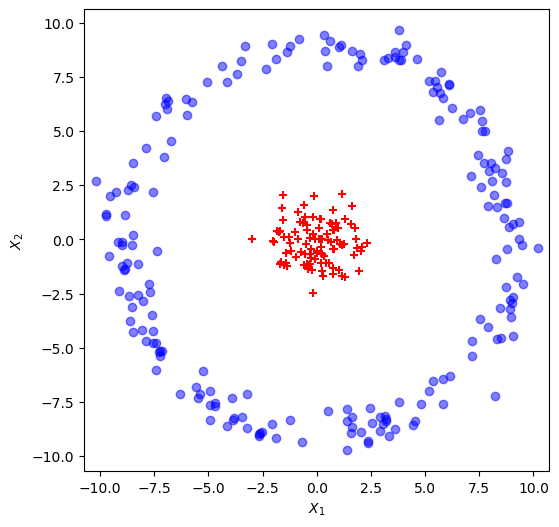

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate central cluster data
np.random.seed(100)
num_points_center = 100
center_data = np.random.normal(0, 1, (num_points_center, 2))

# Generate ring cluster data
num_points_ring = 200
radius_mean = 9
radius_std = 0.5
angles = np.random.uniform(0, 2 * np.pi, num_points_ring)
radii = np.random.normal(radius_mean, radius_std, num_points_ring)
ring_data_x = radii * np.cos(angles)
ring_data_y = radii * np.sin(angles)
ring_data = np.vstack((ring_data_x, ring_data_y)).T

# Plot the generated data
plt.figure(figsize=(6, 6))
plt.scatter(center_data[:, 0], center_data[:, 1], color='red', marker='+', label='Central Cluster')
plt.scatter(ring_data[:, 0], ring_data[:, 1], edgecolor='blue', facecolor='blue', alpha=0.5, label='Ring Cluster')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.axis('equal')
plt.show()

We try to represent the data in polar coordinates.

In [13]:
polared_center_data = np.array([[np.sqrt(x1**2 + x2**2), np.arctan(x2 / x1)] for x1, x2 in center_data])
polared_ring_data = np.array([[np.sqrt(x1**2 + x2**2), np.arctan(x2 / x1)] for x1, x2 in ring_data])

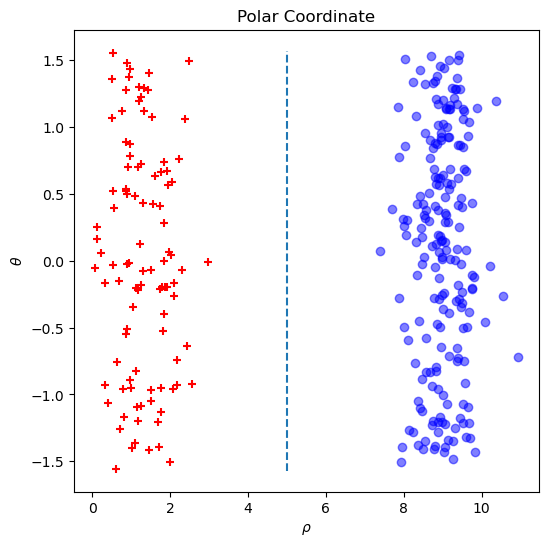

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(polared_center_data[:, 0], polared_center_data[:, 1], color='red', marker='+', label='Central Cluster')
plt.scatter(polared_ring_data[:, 0], polared_ring_data[:, 1], edgecolor='blue', facecolor='blue', alpha=0.5, label='Ring Cluster')
plt.vlines(5, -np.pi / 2, np.pi / 2, linestyles='dashed')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\theta$')
plt.title('Polar Coordinate')
plt.show()

We can then propose a feature map which maps Euclidean coordinates to polar coordinates and take the norm only as angles do not contribute to classification.

$$\phi(\mathbf{x}) = \sqrt{x_1^2 + x_2^2}$$


# 

Since we have $k(x_i, x_j) = \langle \phi(x_i), \phi(x_j)\rangle_{\mathcal{H}} = (K)_{ij}$. The matrix $K$ can be written as:

\begin{align*}
K &= \Phi\Phi^\intercal = 
\begin{bmatrix}
     \text{---}& \phi(x_1)&\text{---}  \\
     \text{---}& \phi(x_2)&\text{---}  \\
    & \vdots & \\
     \text{---}& \phi(x_m)&\text{---}
\end{bmatrix}
\begin{bmatrix}
     \vert& \vert& & \vert  \\
     \phi(x_1)^\intercal& \phi(x_2)^\intercal& \dots& \phi(x_m)^\intercal  \\
    \vert& \vert& & \vert
\end{bmatrix}
\end{align*}

where $\phi(x_i)$ is a row vector.

We assume $K$ is positive semi-definite as this is required to make kernel valid. We can work on eigendecomposition of $K$.
\begin{align*}
K &= PDP^\intercal \\
&= P\sqrt{D}\sqrt{D}P^\intercal \\
&= \left(P\sqrt{D}\right)\left(P\sqrt{D}\right)^\intercal
\end{align*}

where the first equality holds because of symmetric real matrix whose eigenvectors are orthonormal.

Hence we can define $$\Phi := P\sqrt{D}$$

# 

We have:
$$f = \sum_{i=1}^n \alpha_i \left(\phi(x_i) - \frac{1}{n}\sum_{j=1}^n \phi(x_j)\right) = \sum_{i=1}^n \alpha_i\tilde{\phi}(x_i) = \Phi^\intercal H\alpha$$
$$g = \sum_{i=1}^n \beta_i \left(\psi(y_i) - \frac{1}{n}\sum_{j=1}^n \psi(y_j)\right) = \sum_{i=1}^n \beta_i\tilde{\psi}(y_i) = \Psi^\intercal H\beta$$

We can do QR decomposition on $f$ and $g$. 
$$f = QRH\alpha$$
$$g = SPH\beta$$

where $Q$ and $R$ are orthonormal matrices with size $d_x \times m_x$ ($d_y \times m_y$ resp.), $R$ and $P$ are upper triangular matrices with size $m_x \times n$ ($m_y \times n$ resp.).

We denote:

$$\theta := RH\alpha$$
and
$$\eta := PH\beta$$

$f$ and $g$ will be the linear combination of orthonormal basis. Specifically:
$$f = \sum_i^{m_x}\theta_i\mathbf{q}_i$$
$$g = \sum_i^{m_y}\eta_i\mathbf{s}_i$$

Effectively $f$ and $g$ lie in the subspace spanned by the pivot features. Pivot features usually are much smaller than the original feature space. This can greatly reduces the computational complexity.

We have:

$$||f||_{\mathcal{F}}^2 = \alpha^\intercal H R^\intercal RH\alpha = \theta^\intercal\theta$$

$$||g||_{\mathcal{G}}^2 = \beta^\intercal H P^\intercal PH\beta = \eta^\intercal\eta$$

and

$$\langle f, C_{\tilde{\phi}(x)\tilde{\psi}(y)} g\rangle_{\mathcal{F}} = \frac{1}{n}\alpha^\intercal\tilde{K}\tilde{L}\beta = \frac{1}{n}\alpha^\intercal HR^\intercal RHP^\intercal PH\beta = \frac{1}{n}\theta^\intercal RHP^\intercal\eta$$

The Lagrangian problem becomes:
$$\mathcal{L}(f, g, \lambda, \gamma) = -\frac{1}{n}\theta^\intercal RHP^\intercal\eta + \frac{\lambda}{2}(\theta^\intercal\theta-1) + \frac{\gamma}{2}(\eta^\intercal\eta-1)$$

Similar to the original problem, we get the equation:
$$
\begin{bmatrix}
0&\frac{1}{n}RHP^\intercal\\
\frac{1}{n}PHR^\intercal&0
\end{bmatrix}
\begin{bmatrix}
\theta\\
\eta
\end{bmatrix}
=
\gamma
\begin{bmatrix}
\theta\\
\eta
\end{bmatrix}
$$
So we can solve the eigenvalue problem with
$$A = \begin{bmatrix}
0&\frac{1}{n}RHP^\intercal\\
\frac{1}{n}PHR^\intercal&0
\end{bmatrix}$$

$A$ is of size $(m_x+m_y)\times(m_x+m_y)$.

When we do the evaluation, we have
$$f(x) = \langle f, \phi(x)\rangle_{\mathcal{F}} = \alpha^\intercal HR^\intercal \mathbf{r} = \theta^\intercal \mathbf{r}$$
where $\mathbf{r}$ is a column vector of size $m_x$ such that $\phi(x) = Q\mathbf{r}$.

The original COCO computation involves costs:

* Computing $K$ and $L$: $O(n^2)$
* Applying demean to $K$ and $L$: $O(n^2)$ because of special structure of H. $\tilde{K} = \left(I - \frac{1}{n}\mathbf{1}_n\mathbf{1}_n^\intercal\right)K\left(I - \frac{1}{n}\mathbf{1}_n\mathbf{1}_n^\intercal\right) = K - \frac{1}{n}\mathbf{1}_n\mathbf{1}_n^\intercal K - \frac{1}{n}K\mathbf{1}_n\mathbf{1}_n^\intercal + \frac{1}{n^2}\mathbf{1}_n\mathbf{1}_n^\intercal K \mathbf{1}_n\mathbf{1}_n^\intercal$
* Generalised eigenvalue problem solving: $O(n^3)$
* Total cost is $O(n^3)$

For incomplete Cholesky Decomposition approximation:

* Computing $K$ and $L$: $O(n^2)$
* Computing incomplete Cholesky Decomposition: $O(nm^2)$
* Applying demean: $O(nm)$
* Solving eigenvalue problem: $O(m^3)$
* Total cost is $O(nm^2+m^3)$

For $m \ll n$, the incomplete Cholesky Decomposition approximation is much faster.

In [190]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [191]:
def generate_data(num):
    """
    Input: 
    num: Number of data x and y such that

    x = sin(t) + n1
    y = cos(t) + n2
    n1, n2 ~ N(0, 0.01^2)
    t ~ Unif(0, 2pi)
    """

    ns = np.random.normal(0, 0.01, (num, 2))
    ts = np.random.uniform(0, 2.0 * np.pi, num)
    xs = np.sin(ts) + ns[:, 0]
    ys = np.cos(ts) + ns[:, 1]
    return xs, ys

In [192]:
np.random.seed(100)
n = 500
X, Y = generate_data(n)

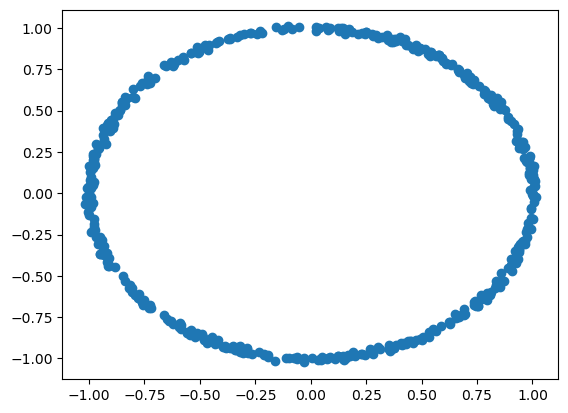

In [193]:
plt.scatter(X, Y)

In [194]:
def gaussian_kernel(sigma, X, Y):
    """
    Calculate gaussian kernel
    gaussian kernel is defined as exp(-||x_i - y_i||^2 / (2sigma^2))
    """
    X = X.reshape(-1, 1)
    Y = Y.reshape(-1, 1)
    K = np.exp(-(X - Y.T)** 2 / (2 * sigma** 2))
    return K

In [195]:
class QR_decomposition:
    """
    Perform QR decomposition for feature map and use for kernel calculation
    """

    def __init__(self, X, sigma):
        self._data = X

        # sigma: used for gaussian kernel
        self._sigma = sigma
        
        self._n = X.shape[0]

        # K: [n, n] np array, gram kernel matrix
        self._K = gaussian_kernel(self._sigma, X[:, None], X[:, None])

    def incomplete_cholesky_decomposition(self, eta):
        """
        perform incomplete cholesky decomposition with threshold eta

        Input:
        eta: scalar, threshold under which the residual norm will be ignored

        Output:
        r: [m, n] np array, un upper triangular matrix with size of m by n, m is the size of residual norms larger than eta
        """
        R = np.zeros((self._n, self._n))
        d = np.diag(self._K).copy()
        j = 0
        arg_a = np.argmax(d)
        a = d[arg_a]
        self._permutation_idx = [arg_a]
        self._nu = []

        while a > eta:
            nu_j = np.sqrt(a)
            self._nu.append(nu_j)
            for i in range(self._n):
                R[j, i] = (self._K[self._permutation_idx[-1], i]) / nu_j
                if j > 0:
                    R[j, i] -= np.dot(R[:j, i], R[:j, self._permutation_idx[-1]]) / nu_j
                d[i] -= R[j, i]**2
            arg_a = np.argmax(d)
            self._permutation_idx.append(arg_a)
            a = d[arg_a]
            j += 1
            if j >= self._n:
                break

        m = j
        self._incompletle_R = R[:m, :]
        return self._incompletle_R

    def r_from_new_data(self, new_data):
        """
        Input:
        X: [n, d] np array, original n data set
        R: [m, n] np array, partial Gram-Schmidt orthonormalisation
        new_data: [l, d] np array, new data of size l, each data has d dimension

        Output:
        r: [m, l] np array, l new columns
        """
        K = gaussian_kernel(self._sigma, self._data[:, None], new_data)
        m = self._incompletle_R.shape[0]
        l = new_data.shape[0]
        r = np.zeros((m, l))
        for j in range(m):
            for i in range(l):
                r[j, i] = (K[self._permutation_idx[j], i] - np.dot(r[:j, i], self._incompletle_R[:j, self._permutation_idx[j]])) / self._nu[j]
        return r



In [196]:
# Test cholesky decomposition is correct
test_A = np.array([[1, 0.6, 0.2],
                   [0.6, 1, -0.4],
                   [0.2, -0.4, 1]])
eivalues, eivectors = np.linalg.eig(test_A)
print(np.all(eivalues > 0))
dummy_QR = QR_decomposition(np.ones(test_A.shape[0]), 1.0)
dummy_QR._K = test_A
test_R = dummy_QR.incomplete_cholesky_decomposition(0)
test_A_ = test_R.T @ test_R
print(np.max(np.abs((test_A - test_A_).flatten())))

True
2.220446049250313e-16


In [197]:
sigma = 0.5
X_QR = QR_decomposition(X, sigma)
Y_QR = QR_decomposition(Y, sigma)

In [198]:
R = X_QR.incomplete_cholesky_decomposition(1.0e-6)
P = Y_QR.incomplete_cholesky_decomposition(1.0e-6)

In [199]:
m_K = R.shape[0]
m_L = P.shape[0]
print(R.shape)
print(P.shape)

(11, 500)
(11, 500)


We reduced the dimension from $n = 500$ to $m=11$.

In [200]:
# Test R^T R = K within error < threshold
print(np.max(np.abs(R.T @ R - X_QR._K)))
print(np.max(np.abs(P.T @ P - Y_QR._K)))

3.10812952042383e-07
1.3650072383519785e-07


In [201]:
# Test calculating new column is correct
test_r_x = X_QR.r_from_new_data(X[:, None])
print(np.max(np.abs((test_r_x - R).flatten())))
test_r_y = Y_QR.r_from_new_data(Y[:, None])
print(np.max(np.abs((test_r_y - P).flatten())))

3.607497330374021e-13
2.0553659685687564e-13


In [202]:
H = np.eye(n) - np.ones((n, n)) / n
RHP = R @ H @ P.T / n
approx_A = np.block([
    [np.zeros((m_K, m_K)), RHP],
    [RHP.T, np.zeros((m_L, m_L))]
])

In [203]:
approx_eivalues, approx_eivectors = np.linalg.eig(approx_A)

In [204]:
arg_coco = np.argmax(np.real(approx_eivalues))
coco = np.real(approx_eivalues[arg_coco])
coco

0.1345063638315116

In [205]:
theta, lmbda = np.real(approx_eivectors[:m_K, arg_coco]), np.real(approx_eivectors[m_K:, arg_coco])
theta = theta / np.linalg.norm(theta)
lmbda = lmbda / np.linalg.norm(lmbda)

# Sanity check if the eigenvalue and eigenvector are correct
print(np.max(np.abs(approx_A @ np.block([theta, lmbda]) - coco * np.block([theta, lmbda]))))


1.249000902703301e-16


In [206]:
# Sanity check if theta and lmbda have unit norm
print(np.linalg.norm(theta))
print(np.linalg.norm(lmbda))

1.0
1.0


In [207]:
theta

array([ 4.05667160e-01, -3.66160016e-01,  6.51564299e-01, -5.15695831e-01,
       -6.59969027e-02,  7.41167936e-02, -2.84659274e-02, -1.46002828e-02,
        2.27414797e-03, -2.28252118e-03, -1.49934969e-04])

In [208]:
lmbda

array([ 1.53227846e-01,  4.15775463e-01, -8.55428282e-01, -2.52170945e-01,
       -6.35969112e-02,  5.36051254e-02,  3.70910537e-02, -2.97405854e-03,
        5.49384934e-04, -7.20076741e-04,  8.78604754e-04])

In [209]:
lin_space = np.arange(-1, 1, 0.1)
r_x = X_QR.r_from_new_data(lin_space[:, None])
new_fx = (theta[None, :] @ r_x).flatten()
r_y = Y_QR.r_from_new_data(lin_space[:, None])
new_fy = (lmbda[None, :] @ r_y).flatten()

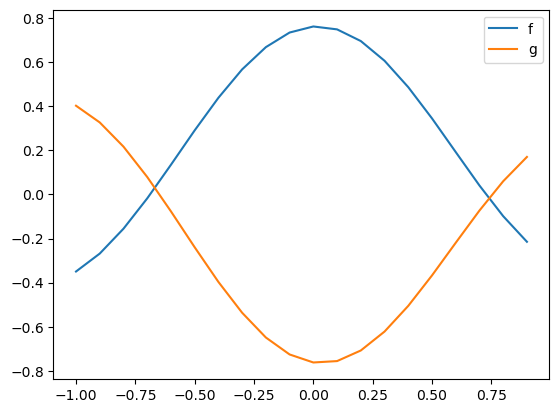

In [210]:
plt.figure()
plt.plot(lin_space, new_fx, label='f')
plt.plot(lin_space, new_fy, label='g')
plt.legend()
plt.show()

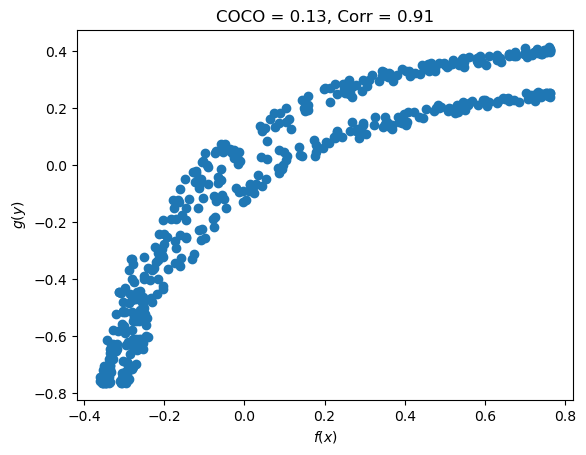

In [211]:
f_x = theta[None, :] @ R
f_y = lmbda[None, :] @ P
correlation = np.corrcoef(f_x.flatten(), f_y.flatten())[0, 1]
plt.figure()
plt.scatter(f_x, f_y)
plt.xlabel('$f(x)$')
plt.ylabel('$g(y)$')
plt.title(f'COCO = {coco:.2f}, Corr = {correlation:.2f}')
plt.show()

# 

From Q3, we already have:
$$\langle f, C_{\tilde{\phi}(x)\tilde{\psi}(y)} g\rangle_{\mathcal{F}} = \frac{1}{n}\alpha^\intercal\tilde{K}\tilde{L}\beta =\frac{1}{n}\theta^\intercal RHP^\intercal\eta$$

Similarly we have:
\begin{align*}
\text{var}\left(f(x)\right) &= \langle f, C_{\tilde{\phi}(x)\tilde{\phi}(x)} f\rangle_{\mathcal{F}}\\
&= \frac{1}{n}\sum_{i=1}^n \langle f, \tilde{\phi}(x_i)\rangle_{\mathcal{F}}^2 \\
&= \frac{1}{n}\sum_{i=1}^n\Big\langle\sum_{l=1}^n\alpha_l\tilde{\phi}(x_l), \tilde{\phi}(x_i)\Big\rangle_{\mathcal{F}}^2\\
&= \frac{1}{n}\alpha^\intercal \tilde{K}^2\alpha\\
&=\frac{1}{n}\theta^\intercal RHR^\intercal\theta
\end{align*}

and
$$\text{var}\left(g(y)\right) = \langle g, C_{\tilde{\psi}(y)\tilde{\psi}(y)} g\rangle_{\mathcal{G}} = \frac{1}{n}\beta^\intercal \tilde{L}^2\beta = \frac{1}{n}\eta^\intercal PHP^\intercal\eta$$

The Lagrangian problem becomes:
$$\mathcal{L}(f, g, \lambda, \gamma) = -\frac{1}{n}\alpha^\intercal\tilde{K}\tilde{L}\beta + \frac{\lambda}{2}\left(\frac{1}{n}\alpha^\intercal \tilde{K}^2\alpha-1\right) + \frac{\gamma}{2}\left(\frac{1}{n}\beta^\intercal \tilde{L}^2\beta-1\right)$$

Taking derivatives regarding $\alpha$ and $\beta$ and set them to 0, we get similar result as in lecture notes that:
$$\lambda = \gamma$$
$$\tilde{K}\tilde{L}\beta = \lambda\tilde{K}^2\alpha$$
$$\tilde{L}\tilde{K}\alpha = \gamma\tilde{L}^2\beta$$

So in matrix form we have:
$$
\begin{bmatrix}
0&\tilde{K}\tilde{L}\\
\tilde{L}\tilde{K}&0
\end{bmatrix}
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}
=
\gamma
\begin{bmatrix}
\tilde{K}^2&0\\
0&\tilde{L}^2
\end{bmatrix}
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}
$$


We know $\tilde{K} = HKH$. With gaussian kernel setup and the assumptions that the sample points are non-pathological and there is no numerical instability, $K$ should be full rank. However, rank of $H$ is $n-1$ as this is a demean matrix.

Since we have $H^2 = H$, this means if $\mathbf{x}$ is the eigenvector of $H$ with corresponding eigenvalue $\lambda$, we have:
$$H\mathbf{x} = H^2\mathbf{x} = H H\mathbf{x} = H\lambda\mathbf{x} = \lambda^2\mathbf{x}$$
$$H\mathbf{1}_n = \mathbf{0}$$

So we have $\lambda^2 = \lambda$. $H$ has eigenvalue 0 or 1. For $\lambda = 0$, we have corresponding eigenvector $\mathbf{1}_n$. For $\lambda=1$, we have any vector orthogonal to $\mathbf{1}_n$ as eigenvectors and the multiplicity is $n-1$.

$\tilde{K}$ and $\tilde{L}$ are singular with rank $n-1$. We can use SVD on them.

$$\tilde{K} = U_K\Lambda_K U_K^T$$

where $U_K$ is of size $n \times (n-1)$ and $\Lambda_K$ is a square diagonal matrix with size $(n-1) \times (n-1)$ and $U_K^TU_K = I_{n-1}$

Note we have $H\tilde{K} = \tilde{K}$,
$$HU_K\Lambda_K U_K^T = U_K\Lambda_K U_K^T$$
Multiplying $U_K$ on both sides:
$$HU_K\Lambda_K = U_K\Lambda_K$$
Since $\Lambda_K$ is invertible, we have
$$HU_K = U_K$$

This indicates $U_K$ are the eigenvectors of $H$ with eigenvalue 1 and $U_KU_K^T = H$ (since the other eigenvalue is 0).

We also have pseudo inverse of 
$$\tilde{K}^\dagger = U_K\Lambda_K^{-1} U_K^T$$
such that 
$$\tilde{K}^\dagger\tilde{K} = H$$

Similar results for $\tilde{L}$.

Go back to the generalised eigenvalue problem, we know $\text{Null}(\tilde{K}) = \{\mathbf{1}_n, \mathbf{0}\}$ and $\text{Null}(\tilde{L})=\{\mathbf{1}_n, \mathbf{0}\}$.

We can observe that 
$$\Bigg\{\begin{bmatrix} \mathbf{1}_n \\ \mathbf{0}\end{bmatrix}, \begin{bmatrix} \mathbf{0} \\ \mathbf{1}_n\end{bmatrix}\Bigg\}$$
are the eigenvectors of the problem with eigenvalue 0 (multiplicity is 2).

We use SVD to express:
$$\tilde{K}\tilde{L}\beta = \lambda\tilde{K}^2\alpha$$
$$U_K\Lambda_K U_K^TU_L\Lambda_L U_L^T\beta = \lambda U_K\Lambda_K U_K^TU_K\Lambda_K U_K^T\alpha = \lambda U_K\Lambda_K^2 U_K^T\alpha$$

Multiply $U_K\Lambda^{-2}U_K^T$ on both side, we have:
$$U_K\Lambda_K^{-1} U_K^TU_L\Lambda_L U_L^T\beta = H\alpha$$
We can use the trick that $U_L^T = U_L^TH$ to have:
$$U_K\Lambda_K^{-1} U_K^TU_L\Lambda_L U_L^TH\beta = H\alpha$$
Similarly we have:
$$U_L\Lambda_L^{-1} U_L^TU_K\Lambda_K U_K^TH\alpha = H\beta$$

Let $\tilde{\alpha} := H\alpha$ and $\tilde{\beta} := H\beta$, these are $\alpha$ and $\beta$ projected onto $\tilde{K}$ and $\tilde{L}$ spaces. The eigenvalue problem becomes:
$$
\begin{bmatrix}
0&U_K\Lambda_K^{-1} U_K^TU_L\Lambda_L U_L^T\\
U_L\Lambda_L^{-1} U_L^TU_K\Lambda_K U_K^T&0
\end{bmatrix}
\begin{bmatrix}
\tilde{\alpha}\\
\tilde{\beta}
\end{bmatrix}
=
\gamma
\begin{bmatrix}
\tilde{\alpha}\\
\tilde{\beta}
\end{bmatrix}
$$

To solve the eigenvalue problem, we have:
\begin{align*}
&\det\left(\begin{bmatrix}
-\gamma I_n&U_K\Lambda_K^{-1} U_K^TU_L\Lambda_L U_L^T\\
U_L\Lambda_L^{-1} U_L^TU_K\Lambda_K U_K^T&-\gamma I_n
\end{bmatrix}\right) \\
& = \det\left(-\gamma I_n\right)\det\left(-\gamma I_n + \frac{1}{\gamma}U_L\Lambda_L^{-1} U_L^TU_K\Lambda_K U_K^TU_K\Lambda_K^{-1} U_K^TU_L\Lambda_L U_L^T\right) \\
& = \gamma^n\det\left(-\gamma I_n + \frac{1}{\gamma}H\right) \\
& = \det\left(H-\gamma^2I_n\right)
\end{align*}

We know $\det(H - \gamma^2 I_n) = 0, \gamma \neq 0 \Rightarrow \gamma = \pm 1$.

In total, we get the result that eigenvalues are always 0 or $\pm 1$, which are independent of data. It does not tell us the correlation of the data.

We can add regularisation onto the constraints. For example:
$$\text{var}\left(f(x)\right) + \frac{\kappa}{n}||f||_{\mathcal{F}} = 1$$
$$\text{var}\left(g(y)\right) + \frac{\kappa}{n}||g||_{\mathcal{G}} = 1$$

In this case, the Lagrangian problem becomes:
\begin{equation}
\tilde{\mathcal{L}}(f, g, \lambda, \gamma) = -\frac{1}{n}\alpha^\intercal\tilde{K}\tilde{L}\beta + \frac{\lambda}{2}\left(\alpha^\intercal \tilde{K}^2\alpha + \kappa\alpha^\intercal \tilde{K}\alpha-n\right) + \frac{\gamma}{2}\left(\beta^\intercal \tilde{L}^2\beta + \kappa\beta^\intercal \tilde{L}\beta-n\right)
\end{equation}

Taking derivatives regarding $\alpha$ and $\beta$ and set them to 0, we get similar results:
$$\lambda = \gamma$$
$$
\begin{bmatrix}
0&\frac{1}{n}\tilde{K}\tilde{L}\\
\frac{1}{n}\tilde{L}\tilde{K}&0
\end{bmatrix}
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}
=
\lambda
\begin{bmatrix}
\tilde{K}^2 + \kappa\tilde{K}&0\\
0&\tilde{L}^2 + \kappa\tilde{L}
\end{bmatrix}
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}
$$

However, in practice, $K$ is usually not full rank due to numerical issue. We can see in Q3 that many eigenvalues are smaller than $10^{-6}$. Similarly, even if we add regularisation, many eigenvalues are still infinity in practice. Please see the below demonstration.

In [212]:
from scipy.linalg import eig

In [213]:
kappa = n * 0.05
K_demean = H @ X_QR._K @ H
L_demean = H @ Y_QR._K @ H

A = np.block([
    [np.zeros((n,n)), K_demean @ L_demean / n],
    [K_demean @ L_demean / n, np.zeros((n,n))]
])

B = np.block([
    [K_demean @ K_demean + kappa * K_demean, np.zeros((n,n))],
    [np.zeros((n,n)), L_demean @ L_demean + kappa * L_demean]    
])

eigenvalues, eigenvectors = eig(A, B)

In [225]:
np.real(eigenvalues[:10])

array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf])

We will use incomplete Cholesky Decomposition to tackle with issue. Similar to Q3, we can convert the problem (1) into

$$\tilde{\mathcal{L}}(f, g, \lambda, \gamma) = -\frac{1}{n}\theta^\intercal RHP^\intercal\eta + \frac{\lambda}{2}\left(\theta^\intercal RHR^\intercal\theta + \kappa\theta^\intercal \theta-n\right) + \frac{\gamma}{2}\left(\eta^\intercal PHP^\intercal\eta + \kappa\eta^\intercal \eta-n\right)$$

And we have the following generalised eigenvalue problem:

$$
\begin{bmatrix}
0&\frac{1}{n}RHP^\intercal\\
\frac{1}{n}PHR^\intercal&0
\end{bmatrix}
\begin{bmatrix}
\theta\\
\eta
\end{bmatrix}
=
\lambda
\begin{bmatrix}
RHR^\intercal + \kappa & 0\\
0&PHP^\intercal + \kappa
\end{bmatrix}
\begin{bmatrix}
\theta\\
\eta
\end{bmatrix}
$$

In [215]:
RHR = R @ H @ R.T
PHP = P @ H @ P.T
approx_B = np.block([
    [RHR + kappa, np.zeros((m_K, m_K))],
    [np.zeros((m_L, m_L)), PHP + kappa]
])

In [216]:
approx_cca_eivalues, approx_cca_eivectors = eig(approx_A, approx_B)

In [217]:
arg_cca = np.argmax(np.real(approx_cca_eivalues))
cca = np.real(approx_cca_eivalues[arg_cca])
cca

0.0019977275258364173

In [218]:
theta_cca, lmbda_cca = approx_cca_eivectors[:m_K, arg_cca], approx_cca_eivectors[m_K:, arg_cca]
# Sanity check if the eigenvalue and eigenvector are correct
print(np.max(np.abs(approx_A @ np.block([theta_cca, lmbda_cca]) - cca * approx_B @ np.block([theta_cca, lmbda_cca]))))

3.642919299551295e-17


In [219]:
normaliser_theta = np.sqrt((theta_cca.T @ RHR @ theta_cca + kappa * theta_cca.T @ theta_cca) / n)
normaliser_lmbda = np.sqrt((lmbda_cca.T @ PHP @ lmbda_cca + kappa * lmbda_cca.T @ lmbda_cca) / n)
theta_cca = theta_cca / normaliser_theta
lmbda_cca = lmbda_cca / normaliser_lmbda

# Sanity check if var(f) + kappa * ||f|| = n
print(theta_cca.T @ RHR @ theta_cca + kappa * theta_cca.T @ theta_cca - n)
# Sanity check if var(g) + kappa * ||g|| = n
print(lmbda_cca.T @ PHP @ lmbda_cca + kappa * lmbda_cca.T @ lmbda_cca - n)

1.1368683772161603e-13
-5.684341886080802e-14


In [220]:
theta_cca

array([ 1.20239412,  1.68631257,  0.22281571,  1.33349677, -0.68575168,
        0.34676691,  0.09256226,  0.84830796, -2.46183944, -0.24823675,
       -2.33682847])

In [221]:
lmbda_cca

array([ 0.98053822,  0.93450535,  1.12595194,  0.23389968,  0.29785437,
        0.70769872, -1.38913183, -0.07634186, -3.3890515 ,  1.26893154,
       -0.6948546 ])

In [222]:
new_fx_cca = (theta_cca[None, :] @ r_x).flatten()
new_fy_cca = (lmbda_cca[None, :] @ r_y).flatten()

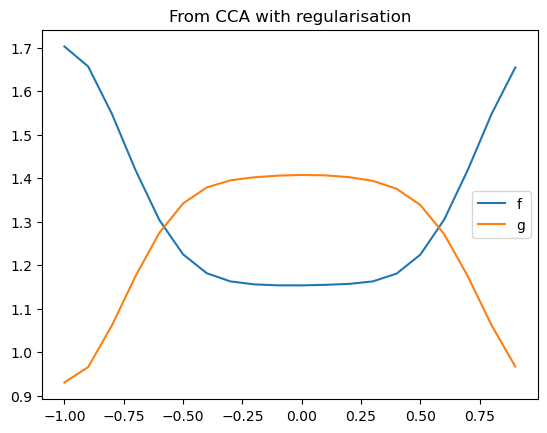

In [223]:
plt.figure()
plt.plot(lin_space, new_fx_cca, label='f')
plt.plot(lin_space, new_fy_cca, label='g')
plt.title('From CCA with regularisation')
plt.legend()
plt.show()

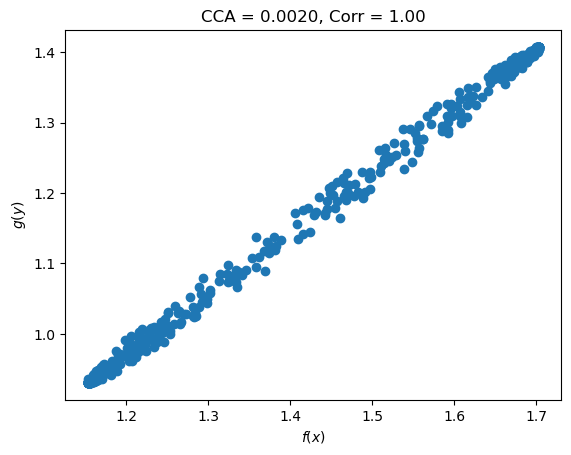

In [224]:
f_x_cca = theta_cca[None, :] @ R
f_y_cca = lmbda_cca[None, :] @ P
correlation_cca = np.corrcoef(f_x_cca.flatten(), f_y_cca.flatten())[0, 1]
plt.figure()
plt.scatter(f_x_cca, f_y_cca)
plt.xlabel('$f(x)$')
plt.ylabel('$g(y)$')
plt.title(f'CCA = {cca:.4f}, Corr = {correlation_cca:.2f}')
plt.show()

$f$ and $g$ in CCA are similar to those in CoCo but they have wider openness and they show much stronger linear correlation between $f(x)$ and $g(y)$.